# Atención y Transformers: La Arquitectura que Conquistó el Mundo

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/04_deep_learning/11_atencion_y_transformers_intro.ipynb)

## Objetivos


- Comprender el colapso de las redes recurrentes (LSTM/GRU) frente a secuencias masivas y el cuello de botella de la paralelización.
- Desmitificar el mecanismo de **Auto-Atención (*Self-Attention*)** y la intuición detrás de *Query, Key, Value* (QKV).
- Implementar un **Mini-Transformer** desde cero utilizando *Subclassing* en Keras 3.
- **Criterio de Ingeniería (El Hambre de Datos):** Demostrar empíricamente por qué los Transformers fallan en datasets pequeños y cómo su verdadero poder se desbloquea al escalar los datos (4,5k vs 77,8k muestras).
- Explorar la universalidad de la arquitectura: De NLP a **Vision Transformers (ViT)** y Series Temporales.



## Prerrequisitos


- Comprensión de datos secuenciales y la capa `Embedding`.
- Haber completado: [Secuencias y NLP: Embeddings, Conv1D y LSTM](10_nlp_embeddings_y_secuencias.ipynb).

---



## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio, descarga los datos e importa utilidades*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    os.chdir(f"../../")

from utils.plots import setup_plot_style
from utils.data import load_dataset
setup_plot_style()

# Configuración Multi-backend de Keras 3
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

keras.utils.set_random_seed(42)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU detectada: {gpus[0].name}")
else:
    print("ADVERTENCIA: No se detectó GPU. El entrenamiento será más lento.")

ADVERTENCIA: No se detectó GPU. El entrenamiento será más lento.


## 1. El Cuello de Botella de la Recurrencia



En el notebook anterior, coronamos a la **BiLSTM** como la reina del procesamiento de secuencias. Sin embargo, las redes recurrentes tienen dos límites físicos y matemáticos infranqueables que impidieron el desarrollo de modelos como ChatGPT:

1. **El Cuello de Botella Secuencial (Hardware):** Para que una LSTM procese la palabra número 100 de un texto, la GPU debe haber terminado de procesar las 99 palabras anteriores en estricto orden. **No se puede paralelizar.** Esto hace que entrenar LSTMs en datasets de billones de palabras tome años, desaprovechando los miles de núcleos de las GPUs modernas.
2. **La Amnesia a Larga Distancia (Semántica):** Incluso con sus compuertas de memoria, una LSTM comprime toda la historia de un párrafo en un solo vector de tamaño fijo (el *Hidden State*). Si la pista clave para entender una frase está en la palabra 1 y la resolución en la palabra 500, la señal matemática se diluye casi por completo.



## 2. La Revolución: *Attention is All You Need*



En 2017, investigadores de Google publicaron un *paper* que cambió la historia de la IA. Propusieron eliminar la recurrencia por completo.

¿Qué pasaría si, en lugar de leer palabra por palabra, la red mira **toda la frase al mismo tiempo** y calcula matemáticamente qué palabras deben "prestarse atención" entre sí?



### La Analogía de la Base de Datos (Q, K, V)


El mecanismo de **Auto-Atención (*Self-Attention*)** funciona como una búsqueda en una base de datos utilizando tres vectores para cada palabra: *Query* (Q), *Key* (K) y *Value* (V).

Por ejemplo, para la frase: *"El banco de la plaza"*.
Cuando la red procesa la palabra **"banco"**:
- Emite un **Query (Q)**: *"Soy un sustantivo ambiguo, busco contexto sobre finanzas o asientos"*.
- Las demás palabras emiten sus **Keys (K)**. La palabra "plaza" emite: *"Soy un lugar al aire libre"*.
- La red calcula la similitud (producto punto) entre el *Query* de "banco" y el *Key* de "plaza". Como coinciden semánticamente, la puntuación de atención es altísima.
- Finalmente, "banco" absorbe el **Value (V)** de "plaza", actualizando su propio significado para entender que se trata de un asiento y no de una institución financiera. Ignora por completo palabras como "el" o "de" (puntuación de atención cercana a cero).

Todo esto ocurre mediante multiplicaciones de matrices masivas que la GPU ejecuta **en un solo paso paralelo**.

## 3. El Problema del Orden: *Positional Encoding*



Si miramos todas las palabras al mismo tiempo, surge un problema grave: para la red, *"Juan mató al oso"* y *"El oso mató a Juan"* son matemáticamente idénticas. Al eliminar la recurrencia, perdimos la noción del tiempo.

**La Solución:** Inyectar el tiempo matemáticamente. Antes de pasar las palabras a la red, sumamos el vector de la palabra (Embedding semántico) con un vector que representa su posición en la frase (Embedding posicional).

Vamos a implementar esto usando *Subclassing* en Keras.



In [2]:
class TokenAndPositionEmbedding(keras.layers.Layer):
    """
    Capa que combina el significado de la palabra con su posición en la secuencia.
    """
    def __init__(self, maxlen, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.maxlen = maxlen
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim

        # Mapa semántico (Palabra -> Vector)
        self.token_emb = keras.layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        # Mapa temporal (Posición 0, 1, 2... -> Vector)
        self.pos_emb = keras.layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        # x contiene los índices de las palabras. Ej: [45, 7, 102, 0, 0]
        maxlen = tf.shape(x)[-1]
        # Generamos un vector de posiciones: [0, 1, 2, 3, 4]
        positions = tf.range(start=0, limit=maxlen, delta=1)

        # Extraemos los vectores
        pos_vectors = self.pos_emb(positions)
        token_vectors = self.token_emb(x)

        # La magia: Sumamos el significado con el tiempo
        return token_vectors + pos_vectors

    def get_config(self):
        config = super().get_config()
        config.update({'maxlen': self.maxlen, 'vocab_size': self.vocab_size, 'embed_dim': self.embed_dim})
        return config

## 4. Construyendo el Bloque Transformer (*Subclassing* en Acción)


En el Notebook [El Ecosistema Keras y APIs](06_ecosistema_keras_y_apis.ipynb) dijimos que debíamos evitar el *Subclassing* a menos que estuviéramos investigando arquitecturas exóticas. Bueno, **este es ese momento**.
El bloque Transformer no es una capa estándar lineal; tiene flujos de datos paralelos, conexiones residuales y normalizaciones internas complejas. Escribirlo como una clase personalizada (`keras.layers.Layer`) nos da el control absoluto necesario para implementar el Estado del Arte (SOTA).





Un bloque Transformer estándar tiene:

1. **Multi-Head Attention:** Varias "cabezas" de atención en paralelo. Una cabeza puede buscar relaciones gramaticales (sujeto-verbo), mientras otra busca relaciones de sentimiento (adjetivo-sustantivo).
2. **Layer Normalization:** A diferencia de las imágenes donde usamos *Batch Normalization*, en texto las secuencias varían mucho. *Layer Norm* normaliza las características de cada palabra individualmente, siendo mucho más estable.
3. **Conexiones Residuales:** Sumamos la entrada original a la salida de la atención. Vital para que los gradientes fluyan en redes profundas.
4. **Feed-Forward Network (FFN):** Un pequeño MLP que procesa el resultado final. Se utiliza activación GELU, reemplaza a ReLU; usada en GPT-2/3, BERT, LLaMA. Es más suave y empíricamente superior en Transformers

### Anatomía del Bloque (Pre-Norm vs Post-Norm)


El paper original de 2017 usaba *Post-Norm* (Normalizar después de sumar la conexión residual). Sin embargo, la industria moderna (desde GPT-3 más o menos...) usa **Pre-Norm** (Normalizar antes de la atención y el FFN) porque estabiliza los gradientes en redes muy profundas. Implementamos la versión moderna, va con par de acotaciones y todo en los comentarios:

In [3]:
class TransformerBlock(keras.layers.Layer):
    """
    Bloque Transformer completo: Multi-Head Attention + FFN + LayerNorm + Residuals.

    Implementa la variante **Pre-Norm** (moderna), usada en GPT-2/3, LLaMA, PaLM, etc.:
        output = x + SubLayer(LayerNorm(x))

    A diferencia del paper original de 2017 (Post-Norm):
        output = LayerNorm(x + SubLayer(x))

    Pre-Norm estabiliza los gradientes en redes muy profundas al mantener
    la magnitud de los residuales estable a lo largo de las capas.
    """
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim    = ff_dim
        self.rate      = rate

        # --- Mecanismo de Atención ---
        # key_dim = embed_dim // num_heads
        # Cada cabeza opera en un subespacio de dimensión d_k = d_model / h
        # Pasar embed_dim completo inflaría las proyecciones a num_heads * embed_dim.
        self.att = keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads
        )

        # --- Red Feed-Forward ---
        # MEJORA: activación GELU en lugar de ReLU.
        # GELU (Gaussian Error Linear Unit) es la elección estándar en modelos modernos
        # (GPT-2/3, BERT, LLaMA). Es diferenciable en 0 y empíricamente superior a ReLU
        # en la mayoría de benchmarks de NLP.
        self.ffn = keras.Sequential([
            keras.layers.Dense(ff_dim, activation='gelu'),  # ← GELU reemplaza ReLU
            keras.layers.Dense(embed_dim),
        ])

        # --- Normalización y Regularización ---
        # Pre-Norm: dos LayerNorm que se aplican ANTES de cada sub-capa.
        self.layernorm1 = keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1   = keras.layers.Dropout(rate)
        self.dropout2   = keras.layers.Dropout(rate)

    def call(self, inputs, training=False):
        # ── Pre-Norm: Normalizar ANTES de la sub-capa ──────────────────────────
        #
        # Variante moderna (Pre-Norm):
        #   out = x + SubLayer(LayerNorm(x))

        # 1. Pre-Norm → Auto-Atención (Query, Key y Value son la misma entrada)
        x_norm1  = self.layernorm1(inputs)                       # normalizar primero
        attn_out = self.att(x_norm1, x_norm1, training=training)
        attn_out = self.dropout1(attn_out, training=training)
        out1     = inputs + attn_out                             # conexión residual

        # 2. Pre-Norm → Feed-Forward
        x_norm2  = self.layernorm2(out1)                         # normalizar primero
        ffn_out  = self.ffn(x_norm2)
        ffn_out  = self.dropout2(ffn_out, training=training)
        return out1 + ffn_out                                    # conexión residual

    def get_config(self):
        config = super().get_config()
        config.update({
            'embed_dim': self.embed_dim,
            'num_heads': self.num_heads,
            'ff_dim':    self.ff_dim,
            'rate':      self.rate,
        })
        return config

> **💡 CRITERIO DE INGENIERÍA: ¿Por qué LayerNorm y no BatchNorm?**
> En imágenes (CNNs), *Batch Normalization* funciona porque los píxeles tienen estadísticas estables a través del lote. En texto, una frase puede tener 5 palabras y otra 50. *Layer Normalization* calcula la media y la varianza **para cada palabra individualmente**, independientemente del resto del lote. Es el estándar absoluto para secuencias.

> Siguen valiendo las nociones fundamentales vistas en los *notebooks* iniciales, cualquier cosa... revisar el *notebook* [Normalización Batch y Layer](03_normalizacion_batch_y_layer.ipynb).

**Nota sobre Pre-Norm en la práctica**:  
En modelos Pre-Norm profundos (como LLaMA), suele agregarse una LayerNorm final después del último bloque Transformer antes del head de clasificación/generación. Esto compensa que, con Pre-Norm puro, la salida del último bloque no pasa por ninguna normalización antes del clasificador. En un stack de bloques, quedaría:


```python
# Ejemplo de stack con Pre-Norm final
x = embedding(tokens)
for block in transformer_blocks:
    x = block(x)
x = final_layernorm(x)   # ← LN final, estándar en LLaMA/GPT-NeoX
logits = output_head(x)
```


## 5. Experimento 1: El Fracaso en Datos Pequeños (Dataset 2022)



Vamos a ensamblar nuestro Mini-Transformer y entrenarlo en el dataset de reseñas de 2022 (~4,500 muestras).

> **⚠️ ALERTA DE INGENIERÍA:**
> En el notebook anterior, una BiLSTM logró un ~82% de *Accuracy* en este mismo dataset. Veamos qué hace la arquitectura "más avanzada del mundo".



In [4]:
# 1. Preparación de datos pequeños (2022)
df_2022 = load_dataset('datasets/cps/reviews_limpias_2022.csv').dropna(subset=['clean_reviews'])
X_2022 = df_2022['clean_reviews'].values
y_2022 = LabelEncoder().fit_transform(df_2022['sentiment'])

X_train_22, X_val_22, y_train_22, y_val_22 = train_test_split(X_2022, y_2022, test_size=0.2, stratify=y_2022, random_state=42)

# 2. Hiperparámetros globales
VOCAB_SIZE = 10000
MAX_LEN = 64
EMBED_DIM = 32
NUM_HEADS = 2
FF_DIM = 64

# 3. Función constructora del modelo End-to-End
def construir_mini_transformer(X_train_text):
    inputs = keras.Input(shape=(1,), dtype=tf.string)

    # Vectorización integrada
    vectorizador = keras.layers.TextVectorization(max_tokens=VOCAB_SIZE, output_sequence_length=MAX_LEN)
    vectorizador.adapt(X_train_text)
    x = vectorizador(inputs)

    # Transformer Pipeline
    x = TokenAndPositionEmbedding(MAX_LEN, VOCAB_SIZE, EMBED_DIM)(x)
    x = TransformerBlock(EMBED_DIM, NUM_HEADS, FF_DIM)(x)

    # Cuello de botella y Salida
    x = keras.layers.GlobalAveragePooling1D()(x)
    x = keras.layers.Dropout(0.1)(x)
    x = keras.layers.Dense(32, activation="relu")(x)
    x = keras.layers.Dropout(0.1)(x)
    outputs = keras.layers.Dense(3, activation="softmax")(x)

    modelo = keras.Model(inputs=inputs, outputs=outputs)
    modelo.compile(optimizer=keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return modelo

# 4. Entrenamiento
print("Entrenando Mini-Transformer en Dataset Pequeño (4.5k muestras)...")
modelo_2022 = construir_mini_transformer(X_train_22)
hist_2022 = modelo_2022.fit(X_train_22, y_train_22,
                            validation_data=(X_val_22, y_val_22),
                            epochs=15,
                            batch_size=64,
                            verbose=1)

print(f"Val Accuracy final: {hist_2022.history['val_accuracy'][-1]:.4f}")

Archivo CSV no encontrado. Descomprimiendo /content/applied-ai-engineering/datasets/cps/reviews_limpias_2022.zip...
Descompresión completa. Intentando cargar el CSV.
Dataset cargado exitosamente con 4558 filas y 6 columnas.
Entrenando Mini-Transformer en Dataset Pequeño (4.5k muestras)...
Epoch 1/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - accuracy: 0.5921 - loss: 0.8338 - val_accuracy: 0.8082 - val_loss: 0.5354
Epoch 2/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.8727 - loss: 0.4046 - val_accuracy: 0.8379 - val_loss: 0.5093
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 133ms/step - accuracy: 0.9184 - loss: 0.2505 - val_accuracy: 0.8423 - val_loss: 0.5631
Epoch 4/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - accuracy: 0.9518 - loss: 0.1759 - val_accuracy: 0.8434 - val_loss: 0.6286
Epoch 5/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 106ms/step - accuracy: 0.9666 - loss: 0.1317 - val_accuracy: 0.8423 - val_loss: 0.6085
Epoch 6/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.9749 - 

**Análisis de Ingeniería**: (Overfitting Masivo)  
Si se observan los logs de entrenamiento, aparece un fenómeno clásico:
- En la época 15, el *Train Accuracy* llega al **~98%** y el *Train Loss* cae a **~0,05**.
- Sin embargo, el *Val Accuracy* se estanca en **~82%** y el *Val Loss* sube a **~0,9**.

In [6]:
# Vistazo rápido a la cantidad de parámetros
modelo_2022.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization_1            │ (None, 64)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_1  │ (None, 64, 32)         │       322,048 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 64, 32)         │        12,736 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,007,819 (3.84 MB)

 Trainable params: 335,939 (1.28 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 671,880 (2.56 MB)

**¿Por qué ocurre esto?**  
Al mirar el `summary()`, el modelo tiene **1.007.819 parámetros**, pero solo le dimos 4.500 frases para aprender. La red tiene tanta capacidad matemática que simplemente **memorizó** el dataset de entrenamiento palabra por palabra, perdiendo la capacidad de generalizar a datos nuevos.
Además, al carecer de sesgo inductivo secuencial (como la LSTM), el Transformer no sabe cómo estructurar el lenguaje con tan pocos ejemplos.

### Análisis del Fracaso: El Sesgo Inductivo


Graficamos la curva de validación de este experimento, casi parece que va empatado o incluso perdiendo contra la BiLSTM antigua. ¿Por qué?

La respuesta es el **Sesgo Inductivo (*Inductive Bias*)**.
- Una **CNN** asume que los píxeles cercanos forman patrones.
- Una **LSTM** asume que los datos son secuenciales y el pasado afecta al futuro.
- Un **Transformer asume absolutamente nada**. Al mirar todas las palabras al mismo tiempo, es una arquitectura extremadamente general.

Para que un Transformer descubra por sí solo las reglas de la gramática, la sintaxis y el sentimiento sin ninguna pista arquitectónica, **necesita una cantidad masiva de datos**. En datasets pequeños, las arquitecturas clásicas (con sesgos fuertes) siempre ganan.

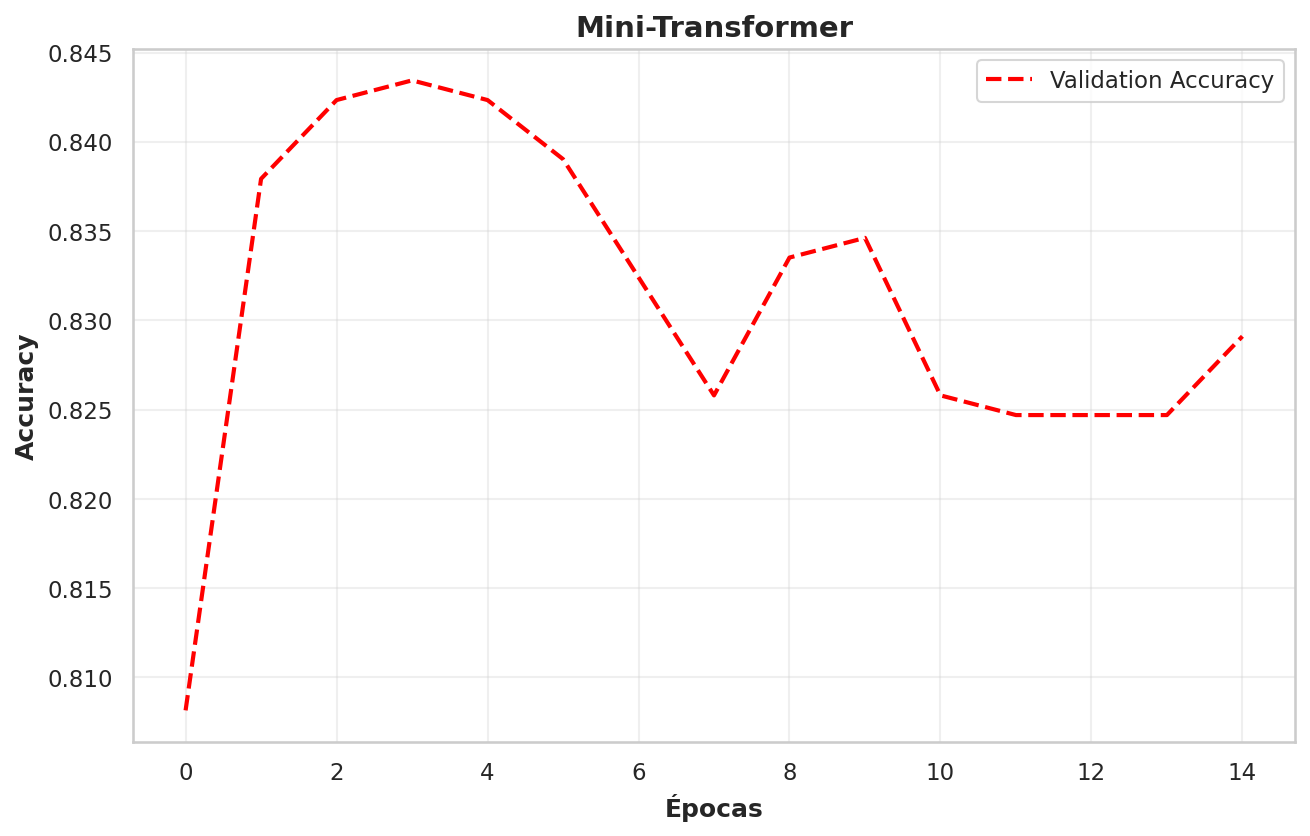

In [7]:
plt.plot(hist_2022.history['val_accuracy'], label='Validation Accuracy', color='red', linestyle='--', linewidth=2)
plt.title("Mini-Transformer", fontsize=14)
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Experimento 2: El Despertar del Gigante (Dataset 2026)



Para demostrar "La Lección Amarga" de la IA (que los datos y el cómputo siempre vencen a los trucos arquitectónicos), vamos a entrenar **exactamente el mismo modelo** en el dataset actualizado de 2026, que contiene ~77.800 reseñas de múltiples categorías (bancarias, gubernamentales, etc.).



Archivo CSV no encontrado. Descomprimiendo /content/applied-ai-engineering/datasets/cps/reviews_2026.zip...
Descompresión completa. Intentando cargar el CSV.
Dataset cargado exitosamente con 77878 filas y 5 columnas.

Entrenando Mini-Transformer en Dataset Masivo (77.8k muestras)...
Epoch 1/15
244/244 ━━━━━━━━━━━━━━━━━━━━ 57s 212ms/step - accuracy: 0.8544 - loss: 0.4156 - val_accuracy: 0.8887 - val_loss: 0.3345
Epoch 2/15
244/244 ━━━━━━━━━━━━━━━━━━━━ 48s 198ms/step - accuracy: 0.9009 - loss: 0.2998 - val_accuracy: 0.8867 - val_loss: 0.3516
Epoch 3/15
244/244 ━━━━━━━━━━━━━━━━━━━━ 46s 189ms/step - accuracy: 0.9118 - loss: 0.2625 - val_accuracy: 0.8821 - val_loss: 0.3999
Epoch 4/15
244/244 ━━━━━━━━━━━━━━━━━━━━ 84s 197ms/step - accuracy: 0.9242 - loss: 0.2309 - val_accuracy: 0.8786 - val_loss: 0.4974
Val Accuracy final: 0.8786


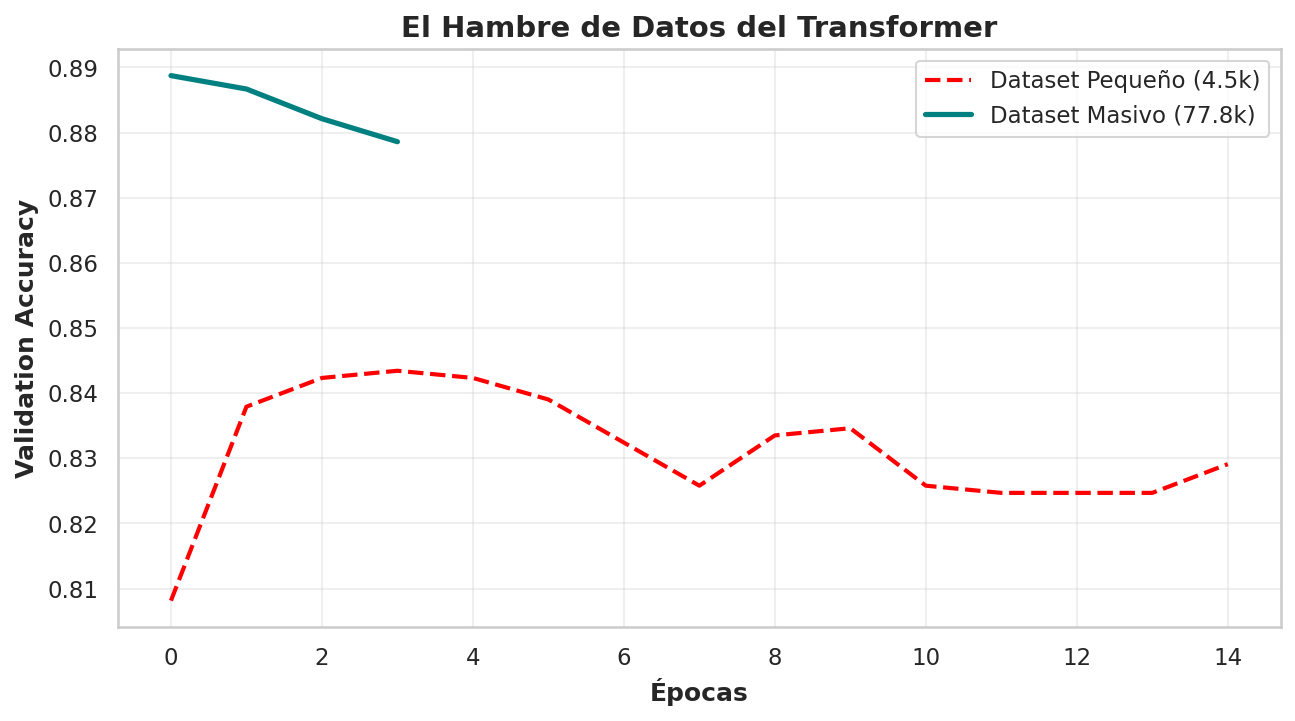

In [8]:
# 1. Preparación de datos masivos (2026)
df_2026 = load_dataset('datasets/cps/reviews_2026.csv').dropna(subset=['content'])
X_2026 = df_2026['content'].values
y_2026 = LabelEncoder().fit_transform(df_2026['sentiment'])

X_train_26, X_val_26, y_train_26, y_val_26 = train_test_split(X_2026, y_2026, test_size=0.2, stratify=y_2026, random_state=42)

# 2. Entrenamiento
print("\nEntrenando Mini-Transformer en Dataset Masivo (77.8k muestras)...")
modelo_2026 = construir_mini_transformer(X_train_26)

# Usamos EarlyStopping porque con tantos datos convergerá rápido
callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]

hist_2026 = modelo_2026.fit(X_train_26, y_train_26,
                            validation_data=(X_val_26, y_val_26),
                            epochs=15,
                            batch_size=256,
                            callbacks=callbacks,
                            verbose=1)

print(f"Val Accuracy final: {hist_2026.history['val_accuracy'][-1]:.4f}")

# 3. Visualización Comparativa
plt.figure(figsize=(10, 5))
plt.plot(hist_2022.history['val_accuracy'], label='Dataset Pequeño (4.5k)', color='red', linestyle='--', linewidth=2)
plt.plot(hist_2026.history['val_accuracy'], label='Dataset Masivo (77.8k)', color='teal', linewidth=2.5)
plt.title("El Hambre de Datos del Transformer", fontsize=14)
plt.xlabel("Épocas")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Comparamos los resultados de este Mini-Transformer (en el dataset masivo) contra la BiLSTM del notebook anterior:

| Arquitectura | Parámetros Entrenables | Tiempo por Época | Val Accuracy | Comportamiento |
| :--- | :--- | :--- | :--- | :--- |
| **BiLSTM** | ~714.000 | ~14s | ~82% | Excelente en datasets pequeños. Lenta de entrenar. |
| **Mini-Transformer** | ~335.000 | ~60s | **~88,8%** | Falla en datasets pequeños. **Domina en datasets masivos.** |

*Nota:* Aunque el Transformer tarda más segundos por época en este experimento, procesa *batches* mucho más grandes en paralelo. A escala industrial (billones de parámetros), la LSTM colapsaría por su naturaleza secuencial, mientras que el Transformer escala linealmente con el hardware (GPUs/TPUs).


**Veredicto de Ingeniería:**  
Observa la curva verde (teal). Al darle suficientes datos, el Transformer "despierta". La curva es suave, estable y alcanza un rendimiento superior en muy pocas épocas. (*El zoom quizá no colabora mucho... usar la imaginación XD*)
Esta es la razón por la que la industria invierte millones en recolectar datos: **Los Transformers son arquitecturas que escalan "infinitamente" con los datos.**



## 7. La Arquitectura Universal: ViT y Series Temporales



Históricamente, la IA estaba fragmentada: los ingenieros de visión usaban CNNs y los de NLP usaban LSTMs. El Transformer unificó el campo.

1. **Vision Transformers (ViT):** ¿Cómo aplicamos atención a una imagen? Simple. Cortamos una imagen de 256x256 en 16 "parches" cuadrados de 16x16. Aplanamos cada parche en un vector (como si fuera una palabra), le sumamos su *Positional Encoding* (para que la red sepa qué parche va arriba a la izquierda), y lo pasamos por el exacto mismo `TransformerBlock` que programamos hoy. Hoy en día, ViT supera a las CNNs en casi todos los benchmarks de visión.
2. **Series Temporales:** En finanzas o predicción climática a largo plazo, los Transformers pueden mirar ventanas de miles de pasos de tiempo simultáneamente, detectando correlaciones estacionales que una LSTM olvidaría.



## Conexiones y Próximos Pasos


Construimos la arquitectura que define el estado del arte actual. Sin embargo, entrenar un Transformer desde cero (como hicimos hoy) es algo que rara vez haríamos en el trabajo diario.

- ➡️ **Siguiente:** En el notebook [Transfer Learning y Fine-Tuning](12_transfer_learning_y_fine_tuning.ipynb), aprendemos a descargar modelos gigantescos (ya sean CNNs para visión o Transformers como BERT para texto) que ya fueron entrenados por Google, Meta u otro laboratorios/personas con billones de datos, y los adaptamos a nuestros problemas específicos en minutos.

## Referencias


### Artículos Fundacionales

1. **Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., ... & Polosukhin, I. (2017)**. *Attention Is All You Need*. Advances in Neural Information Processing Systems (NeurIPS).  
   [[arXiv]](https://arxiv.org/abs/1706.03762)  
   (**El paper más importante de las últimas dos décadas en IA**).

2. **Dosovitskiy, A., et al. (2020)**. *An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale* (ViT).  
   [[arXiv]](https://arxiv.org/abs/2010.11929) (Vision Transformers).

3. **Devlin, J., et al. (2018)**. *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*.  
   [[arXiv]](https://arxiv.org/abs/1810.04805) (El modelo que popularizó los Transformers en NLP).

### Recursos Complementarios

- **Chollet, F. (2021)**. *Deep Learning with Python, Second Edition* (Capítulo sobre Transformers). Manning.
- **The Annotated Transformer** (Harvard NLP) — Implementación comentada línea por línea. [*The Annotated Transformer*](https://nlp.seas.harvard.edu/annotated-transformer/)
- Documentación oficial de Keras: [MultiHeadAttention](https://keras.io/api/layers/attention_layers/multi_head_attention/).

---


## Entorno de Ejecución


In [2]:
from utils.environment import environment_table
environment_table(include_all=False)

Package,Version
Python,3.12.13
Platform,Linux-6.6.122+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
keras,3.13.2
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
